# Практическое задание: Деревья Решений

В этом практическом задании вы будете применять знания о деревьях решений на реальных данных. Выполните задания последовательно, используя подсказки и документацию библиотек при необходимости.

## Цели практического задания:
1. Научиться подготавливать данные для деревьев решений
2. Построить и настроить модель дерева решений
3. Визуализировать и интерпретировать результаты
4. Провести оптимизацию гиперпараметров
5. Оценить производительность модели

## Задание 1: Подготовка данных

1. Импортируйте необходимые библиотеки (numpy, pandas, sklearn, etc.)
2. Загрузите датасет iris из sklearn.datasets
3. Создайте DataFrame с данными и добавьте понятные названия столбцов
4. Проведите базовый анализ данных:
   - Проверьте размер датасета
   - Изучите распределение классов
   - Постройте корреляционную матрицу
   - Визуализируйте распределение признаков

Подсказка: используйте pandas.DataFrame, seaborn.heatmap, plotly для визуализации

(150, 5)
target
0    50
1    50
2    50
Name: count, dtype: int64


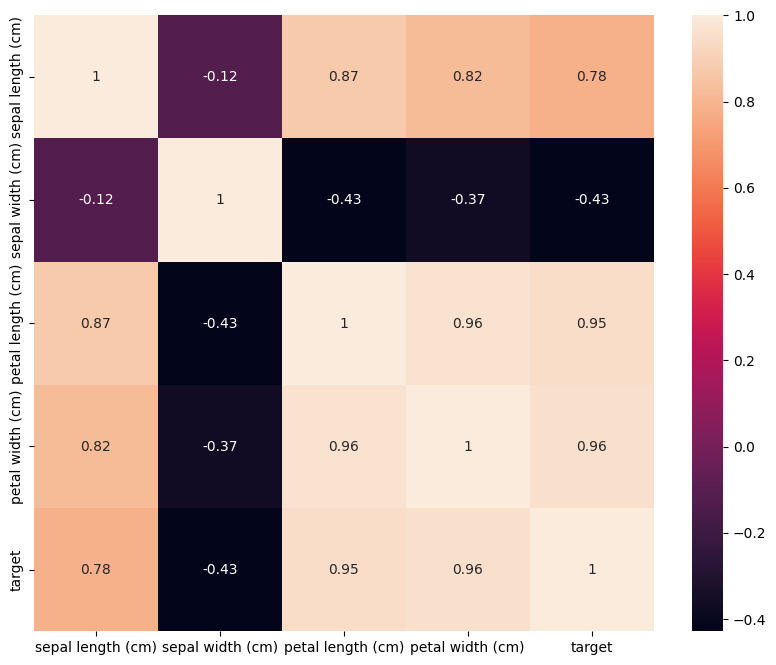

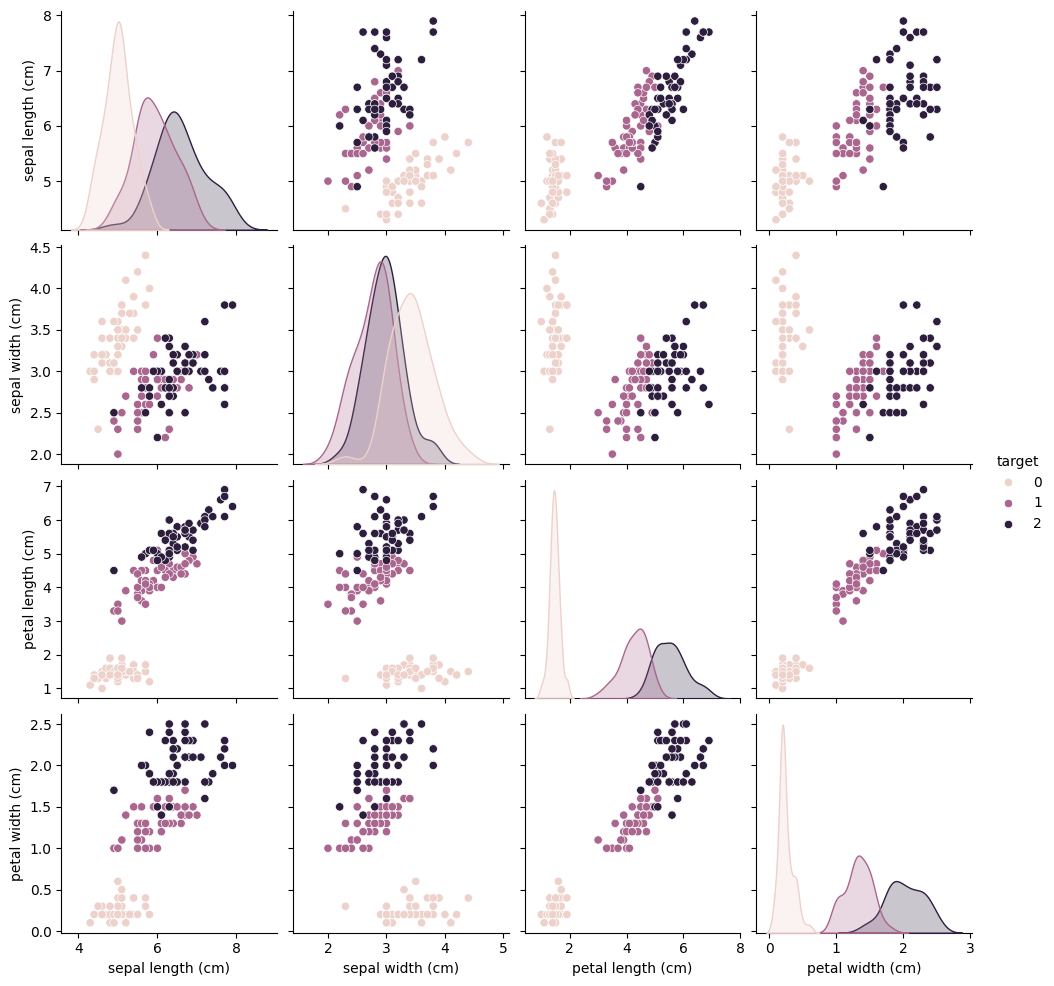

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# размер и классы
print(df.shape)
print(df['target'].value_counts())

# корреляция
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

# графики распределения
sns.pairplot(df, hue='target')
plt.show()

## Задание 2: Построение базовой модели

1. Разделите данные на обучающую и тестовую выборки (test_size=0.2)
2. Создайте и обучите базовое дерево решений без настройки параметров
3. Оцените точность модели на тестовой выборке
4. Выведите отчет о классификации
5. Визуализируйте полученное дерево

Подсказка: используйте train_test_split, DecisionTreeClassifier, classification_report

accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



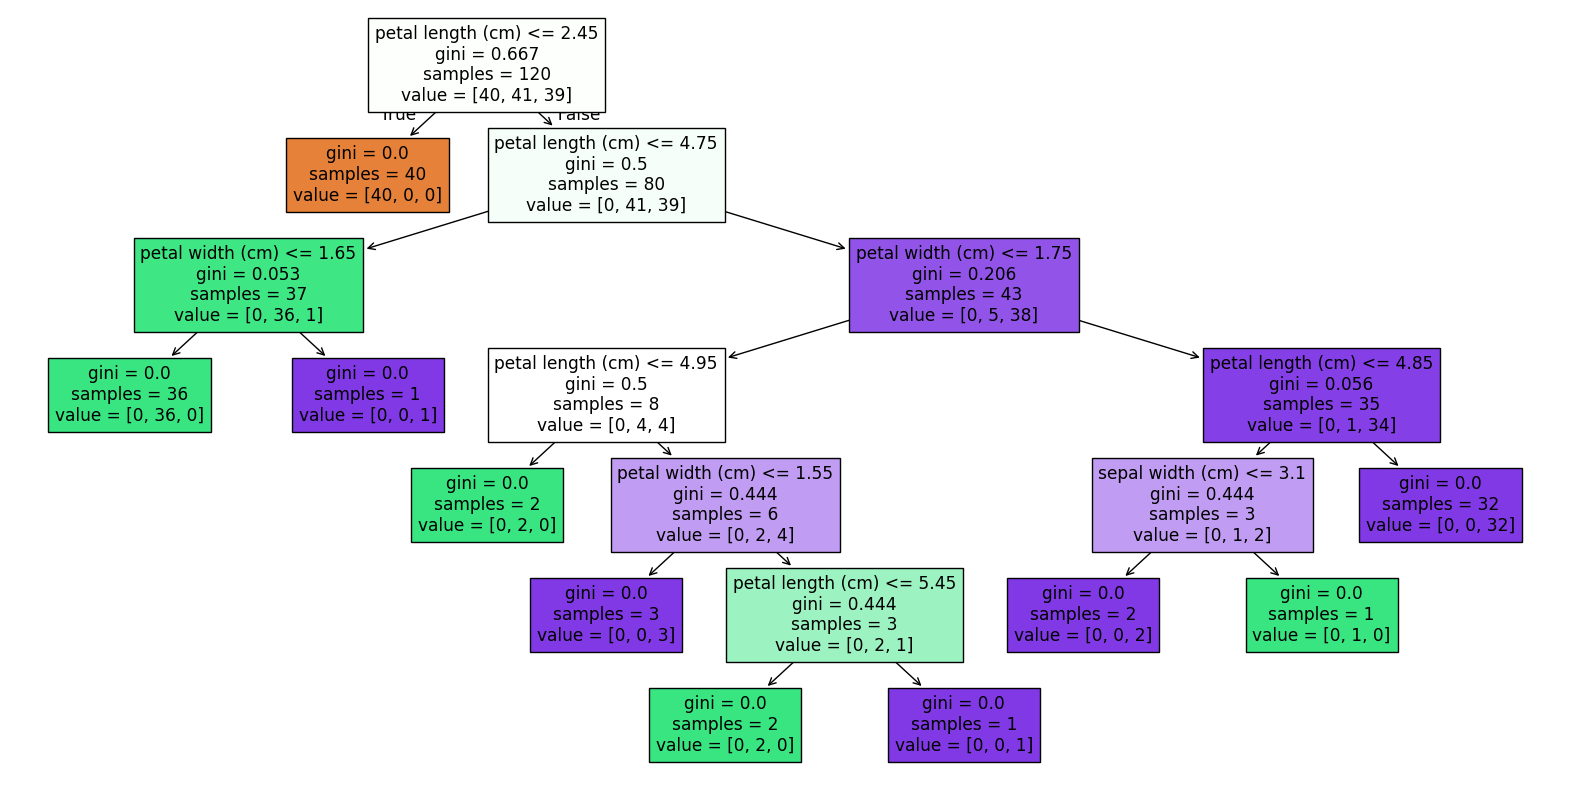

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# отделяем признаки от целевой переменной
X = df.drop('target', axis=1)
y = df['target']

#  трейн и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# создание и обучение модели
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# проверка точности
y_pred = clf.predict(X_test)
print("accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# рисуем дерево
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=iris.feature_names, filled=True)
plt.show()


## Задание 3: Анализ важности признаков

1. Получите и визуализируйте важность признаков из вашей модели
2. Создайте столбчатую диаграмму важности признаков
3. Постройте тепловую карту корреляций для топ-5 важных признаков
4. Проанализируйте, есть ли связь между важностью признаков и их статистическими характеристиками

Дополнительно:
- Попробуйте построить модель, используя только 2 самых важных признака
- Сравните производительность с полной моделью

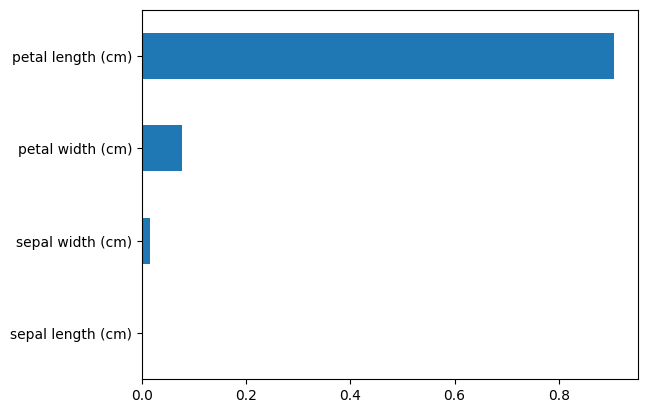

топ 2 признака: Index(['petal length (cm)', 'petal width (cm)'], dtype='object')
accuracy на 2 признаках: 1.0


In [3]:
# важность признаков
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=iris.feature_names)

# график важности
feat_imp.sort_values().plot(kind='barh')
plt.show()

# берем топ-2 признака
top_2 = feat_imp.nlargest(2).index
print("топ 2 признака:", top_2)

# модель на двух признаках
X_small = X[top_2]
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_small, y, test_size=0.2, random_state=42)

clf_small = DecisionTreeClassifier(random_state=42)
clf_small.fit(X_tr_s, y_tr_s)
print("accuracy на 2 признаках:", clf_small.score(X_te_s, y_te_s))

## Задание 4: Оптимизация гиперпараметров

1. Определите сетку параметров для поиска:
   - max_depth: [3, 5, 7, 10]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf: [1, 2, 4]
   - criterion: ['gini', 'entropy']

2. Используйте GridSearchCV для поиска лучших параметров
3. Визуализируйте результаты поиска по сетке
4. Сравните производительность оптимизированной модели с базовой

Дополнительно:
- Попробуйте добавить другие параметры для оптимизации
- Используйте RandomizedSearchCV для сравнения

In [4]:
from sklearn.model_selection import GridSearchCV

# сетка параметров
params = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# поиск
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

print("лучшие параметры:", grid.best_params_)
print("лучший скор на кросс-валидации:", grid.best_score_)

# сохраняем лучшую модель
best_clf = grid.best_estimator_
print("accuracy на тесте:", best_clf.score(X_test, y_test))


лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
лучший скор на кросс-валидации: 0.9583333333333334
accuracy на тесте: 1.0


## Задание 5: Оценка модели

1. Постройте кривые обучения для оптимизированной модели
2. Создайте и визуализируйте:
   - ROC-кривую
   - Precision-Recall кривую
   - Матрицу ошибок

3. Проанализируйте результаты:
   - Есть ли признаки переобучения?
   - Какие классы предсказываются лучше/хуже?
   - Какие метрики наиболее важны для данной задачи?

Дополнительно:
- Попробуйте применить cross_val_score с разным количеством фолдов
- Сравните результаты с другими алгоритмами классификации

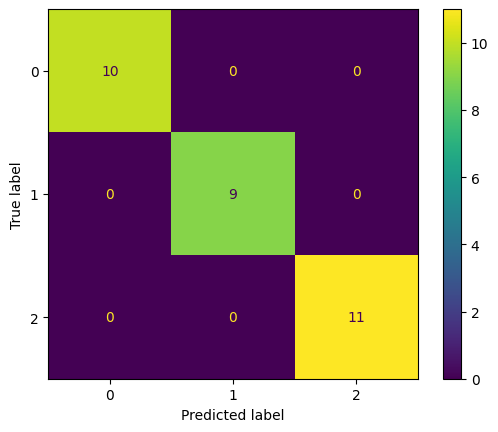

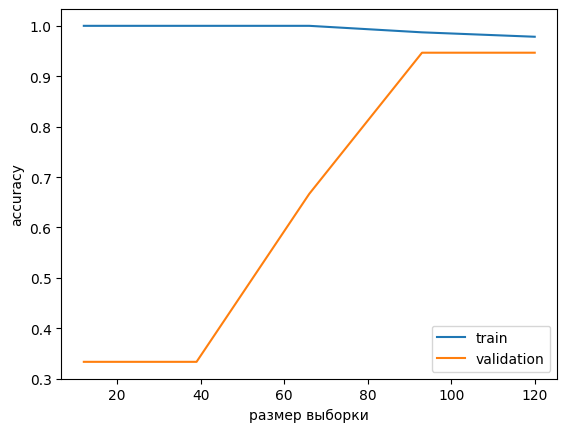

In [5]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# матрица ошибок
cm = confusion_matrix(y_test, best_clf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# кривые обучения
train_sizes, train_scores, test_scores = learning_curve(best_clf, X, y, cv=5)

plt.plot(train_sizes, train_scores.mean(axis=1), label='train')
plt.plot(train_sizes, test_scores.mean(axis=1), label='validation')
plt.xlabel('размер выборки')
plt.ylabel('accuracy')
plt.legend()
plt.show()


## Дополнительные задания

1. **Обработка несбалансированных данных:**
   - Создайте несбалансированный датасет (удалив часть примеров одного класса)
   - Примените техники работы с несбалансированными данными
   - Сравните результаты

2. **Pruning (обрезка дерева):**
   - Реализуйте post-pruning для вашего дерева
   - Сравните производительность до и после обрезки

3. **Визуализация решений:**
   - Создайте функцию для отображения пути принятия решений для конкретного примера
   - Визуализируйте области решений на плоскости (для 2 признаков)

4. **Сравнение с ансамблями:**
   - Сравните ваше лучшее дерево с Random Forest
   - Проанализируйте различия в производительности и интерпретируемости

In [ ]:
# почему
